# 02 信号処理 - 時系列XRDパターン解析

**目的**:  
316パターンの時系列XRDデータに対し、スムージング・ベースライン補正・ピーク検出・相変化追跡を実施。
La2Ni3→LaNi2Hx の水素化反応を特定するための前処理パイプライン。

## 対象読者・前提知識・動作環境・版とライセンス

**対象読者**:  
ARIMデータポータル会員の研究者・技術者を想定しています。`01_eda.ipynb`で本データセットの全体像を把握済みであることを前提とします。scipyによる信号処理（スムージング・ピーク検出）は初めて触れる方でも理解できるよう、都度基礎から説明します。

**シリーズ構成**:  
本ノートブックは「La2Ni3高圧水素化その場観察XRD」4部作の第2部です（第1部: `01_eda.ipynb`、第3部: `03_machine_learning.ipynb`、第4部: `04_data_analysis_summary.ipynb`）。

**動作環境**:  
Python 3.13、pandas・numpy・matplotlib・scipyで動作確認しています。

**データの出典・ライセンス**:  
`01_eda.ipynb`と同じくARIMデータポータルのデータセット（課題番号22QS0007）を使用します。詳細は`01_eda.ipynb`冒頭を参照してください。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
! pip install matplotlib_fontja
! git clone https://github.com/ARIM-Usecase/Claude_Cowork.git
%cd Claude_Cowork

## 0. データセットの読み込みと前処理

### ライブラリのインポート
本コードで扱うpythonのライブラリをimport文でロードします。 

In [1]:
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja

from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import uniform_filter1d

warnings.filterwarnings("ignore")

### 作業フォルダーの設定
プロジェクトルート:  
Jupyterは通常notebookファイルのあるフォルダをカレントディレクトリとして起動するため、Path.cwd()がそのままプロジェクトルートになります。

In [2]:
BASE_DIR = Path.cwd()
DATA_PROC = BASE_DIR / "data" / "processed"
XRD_SEQ = DATA_PROC / "xrd" / "sequential"
XRD_REF = DATA_PROC / "xrd" / "reference"
META_DIR = DATA_PROC / "metadata"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

### 定義関数

In [5]:
def energy_to_d(energy_keV, two_theta_deg=6.0):
    """エネルギー(keV)からd間隔(Å)への変換。詳細は01_eda.ipynbのenergy_to_d()を参照"""
    theta_rad = np.radians(two_theta_deg / 2)
    return 12.398 / (2 * np.sin(theta_rad) * energy_keV)

### 測定データの読み込み

In [7]:
df_meta = pd.read_csv(META_DIR / "metadata_table.csv")
df_seq_meta = df_meta[df_meta["filename"].str.startswith("seq")].reset_index(drop=True)
print(f"Metadata loaded: {len(df_seq_meta)} sequential patterns")

df_seq_meta

Metadata loaded: 316 sequential patterns


,index,filename,time,temperature_K,pressure_GPa,press_load_ton,measurement_mode,live_time_sec,dead_time_pct,2theta_deg,heating_conditions,remark
0,3,seq_0001,2022-07-31 10:41:12,311.48,1.00,10.00,Separate,54.22,10.53,6.0,V(V)=5.14 C(A)=0.41 P(W)=2.13 R(OHM)=12.396,NaN
1,4,seq_0002,2022-07-31 10:42:13,395.00,1.00,10.00,Separate,53.52,10.53,6.0,V(V)=13.92 C(A)=1.28 P(W)=17.82 R(OHM)=10.870,NaN
2,5,seq_0003,2022-07-31 10:43:13,473.26,1.00,10.00,Separate,54.12,10.53,6.0,V(V)=21.15 C(A)=1.54 P(W)=32.53 R(OHM)=13.745,NaN
3,6,seq_0004,2022-07-31 10:44:13,473.10,1.00,10.00,Separate,54.59,10.53,6.0,V(V)=20.87 C(A)=1.56 P(W)=32.50 R(OHM)=13.404,NaN
4,7,seq_0005,2022-07-31 10:45:13,473.14,1.00,10.00,Separate,55.06,10.53,6.0,V(V)=20.80 C(A)=1.56 P(W)=32.51 R(OHM)=13.306,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
311,314,seq_0312,2022-07-31 15:52:13,300.15,0.28,2.84,Separate,57.13,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN
312,315,seq_0313,2022-07-31 15:53:14,300.15,0.21,2.08,Separate,57.25,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN
313,316,seq_0314,2022-07-31 15:54:14,300.15,0.13,1.33,Separate,56.94,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN
314,317,seq_0315,2022-07-31 15:55:14,300.15,0.06,0.58,Separate,57.33,10.53,6.0,V(V)=0.00 C(A)=0.00 P(W)=0.00 R(OHM)=0.000,NaN


## 1. 全パターンの2Dマトリクス作成　　

《齋藤さんへの質問予定》　
1. AIでは、次にあるようにあ２Dカラーマップ型の可視化を提案しました。こちらはいかがでしょうか？　（意味があるような図でしょうか）
1. d間隔の測定レンジ、測定ポイント数（エネルギーグリッド間隔）をチャネルなどの表示など、誤りはございませんでしょうか。　　
1. その他、このような全測定データのデータマトリックスにかかる操作・数値化などについて追加すべき点があればコメントがあればご教示ください。


《島田さんへの質問予定》  
2Dマップの作製にかかる事前の軸の処理です。コードの解説を依頼する予定です。

In [8]:
# 全316パターンを2D配列に読み込む（エネルギー軸共通）
seq_files = sorted([f for f in os.listdir(XRD_SEQ) if f.endswith(".csv")])
n_patterns = len(seq_files)

# エネルギー範囲設定（20〜110 keV を使用）
E_MIN, E_MAX = 20.0, 110.0

# 最初のファイルでエネルギーグリッド取得
df0 = pd.read_csv(XRD_SEQ / seq_files[0])
mask_e = (df0["energy"] >= E_MIN) & (df0["energy"] <= E_MAX)
energy_axis = df0["energy"][mask_e].values
d_axis = energy_to_d(energy_axis)
n_ch = len(energy_axis)

print(f"Energy range: {E_MIN}-{E_MAX} keV, number of channels: {n_ch}")
print(f"d-spacing range: {d_axis[-1]:.2f} - {d_axis[0]:.2f} Å")

# 2D配列: (n_patterns × n_ch)
I_matrix = np.zeros((n_patterns, n_ch), dtype=np.float32)

for i, fname in enumerate(seq_files):
    df_xrd = pd.read_csv(XRD_SEQ / fname)
    mask_e_i = (df_xrd["energy"] >= E_MIN) & (df_xrd["energy"] <= E_MAX)
    I_matrix[i, :] = df_xrd["intensity"][mask_e_i].values[:n_ch]

print(f"2D matrix shape: {I_matrix.shape}")
print(f"Intensity range: {I_matrix.min():.1f} - {I_matrix.max():.1f}")

Energy range: 20.0-110.0 keV, number of channels: 2090
d-spacing range: 1.08 - 5.92 Å
2D matrix shape: (316, 2090)
Intensity range: -68.0 - 3378.0


## 2. 2D カラーマップ（エネルギー-時系列）

《齋藤さんへの質問予定》  　
1. ピークシフトの様子が把握できるものであるかと思いますが、このようなヒートマップの情報から実験方法や物質の位相変化の読み取りの情報が得られるものか、ご教示いただけますか。
1. カラーマップ化するにあたり強度をlog値としています。低強度側への配慮すべき点で何か留意することがあればご教示ください。


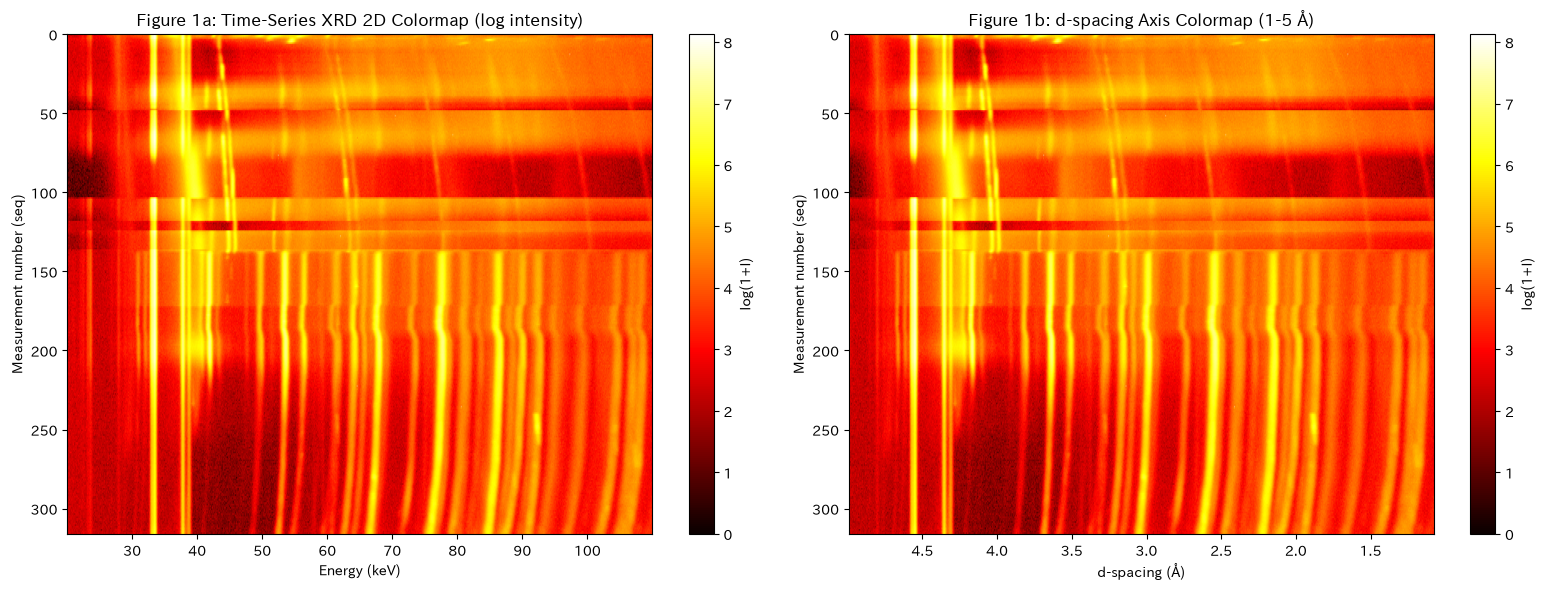

In [9]:
# 温度情報
temps = df_seq_meta["temperature_K"].values[:n_patterns]
pressures = df_seq_meta["pressure_GPa"].values[:n_patterns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# エネルギー軸カラーマップ
im0 = axes[0].imshow(
    np.log1p(I_matrix),
    aspect="auto", origin="upper", cmap="hot",
    extent=[energy_axis[0], energy_axis[-1], n_patterns, 0]
)

axes[0].set_xlabel("Energy (keV)")
axes[0].set_ylabel("Measurement number (seq)")
axes[0].set_title("Figure 1a: Time-Series XRD 2D Colormap (log intensity)")
plt.colorbar(im0, ax=axes[0], label="log(1+I)")

# d値軸カラーマップ（反転）
d_min, d_max = 1.0, 5.0
mask_d = (d_axis >= d_min) & (d_axis <= d_max)
im1 = axes[1].imshow(
    np.log1p(I_matrix[:, mask_d]),
    aspect="auto", origin="upper", cmap="hot",
    extent=[d_axis[mask_d][0], d_axis[mask_d][-1], n_patterns, 0]
)
axes[1].set_xlabel("d-spacing (Å)")
axes[1].set_ylabel("Measurement number (seq)")
axes[1].set_title("Figure 1b: d-spacing Axis Colormap (1-5 Å)")
plt.colorbar(im1, ax=axes[1], label="log(1+I)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig01_xrd_2d_colormap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Savitzky-Golayスムージング

《齋藤さんへの質問予定》  
1. 信号処理でノイズなどの影響を緩和させるなどで使われるスムージングについてお伺いいたします。ここではスペクトル分野ではよく使われるS-G法を使っていますが、放射光でも使われている方法でしょうか。　また、他のスムージング方法はいくつかありますが、特にスムージングにかかるポイントがあればご指摘ください。
1. 残差表示となります。極端にスムージングをされた箇所の確認になりますが、ここでは想定されたものでしょうか。

《島田さんへの質問予定》 pythonでの信号処理でスムージングがある場合には、この分野で別のライブラリがあったりしますか？　（ラマンスペクトルではRamanSPyというライブラリがあり、S-G処理一発で行われたりします）

In [16]:
# スムージング（scipyのsavgol_filterより。　Savitzky-Golay: window=15, polyorder=3）
I_smooth = savgol_filter(I_matrix, window_length=15, polyorder=3, axis=1)
I_smooth = np.clip(I_smooth, 0, None)  # 負値を0にクリップ

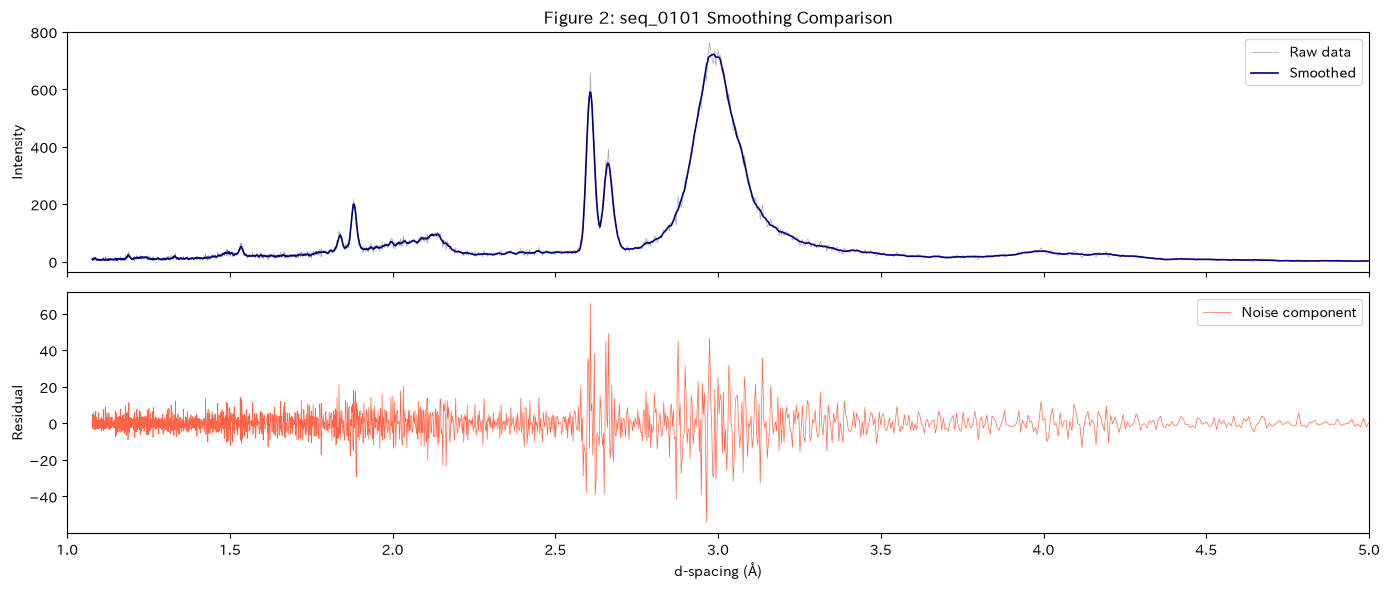

In [13]:
# 比較プロット（seq_0100を例として）
idx_ex = 100
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(d_axis, I_matrix[idx_ex], lw=0.5, alpha=0.7, color="gray", label="Raw data")
axes[0].plot(d_axis, I_smooth[idx_ex], lw=1.2, color="navy", label="Smoothed")
axes[0].set_ylabel("Intensity"); axes[0].legend()
axes[0].set_title(f"Figure 2: seq_{idx_ex+1:04d} Smoothing Comparison")
axes[0].set_xlim(1, 5)

# 残差
axes[1].plot(d_axis, I_matrix[idx_ex] - I_smooth[idx_ex], lw=0.5, color="tomato", label="Noise component")
axes[1].set_xlabel("d-spacing (Å)"); axes[1].set_ylabel("Residual")
axes[1].set_xlim(1, 5); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig02_smoothing_example.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. ベースライン補正（移動最小値法）

《齋藤さんへの質問予定》  
1. ベースライン補正はXRDでも難航するところであるかと思います。理論的なバックグランド、経験的なバックグランドなどについて解説をお願いできますか。
1. AIは、まずは移動最小法を提案してきました。いかがでしょうか。

《島田さんへの質問予定》 pythonでのベースライン補正では、いつもどのようにおこなっていますか。でスムージングがある場合には、この分野で別のライブラリがあったりしますか？　（ラマンスペクトルではさきほどのRamanSPyというライブラリがありります）

In [14]:
#　ベースライン補正の定義
def baseline_correction(spectrum, window=100):
    """移動最小値によるベースライン推定と補正"""
    from scipy.ndimage import minimum_filter1d
    baseline = minimum_filter1d(spectrum.astype(float), size=window)
    return np.clip(spectrum - baseline, 0, None), baseline

# 全パターンにベースライン補正を適用
I_corrected = np.zeros_like(I_smooth)
for i in range(n_patterns):
    I_corrected[i], _ = baseline_correction(I_smooth[i], window=120)

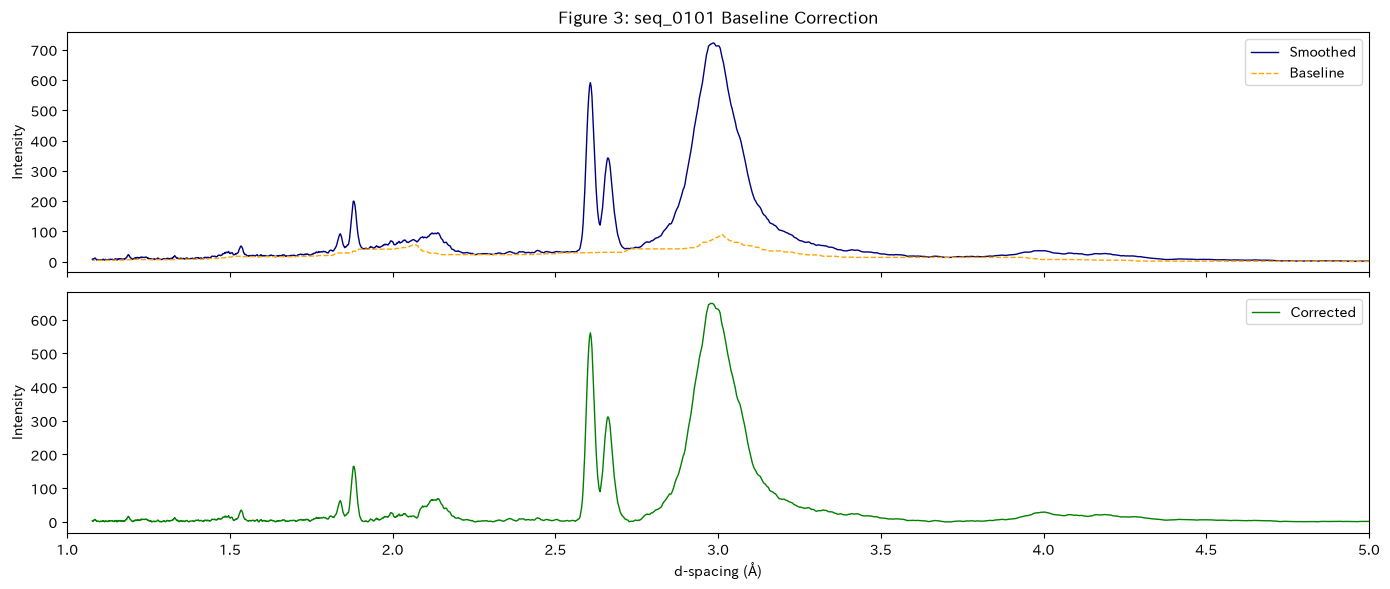

In [15]:
# 確認プロット
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
_, bl = baseline_correction(I_smooth[idx_ex], window=120)
axes[0].plot(d_axis, I_smooth[idx_ex], lw=1, color="navy", label="Smoothed")
axes[0].plot(d_axis, bl, lw=1, ls="--", color="orange", label="Baseline")
axes[0].set_ylabel("Intensity"); axes[0].legend()
axes[0].set_title(f"Figure 3: seq_{idx_ex+1:04d} Baseline Correction")
axes[0].set_xlim(1, 5)

axes[1].plot(d_axis, I_corrected[idx_ex], lw=1, color="green", label="Corrected")
axes[1].set_xlabel("d-spacing (Å)"); axes[1].set_ylabel("Intensity")
axes[1].set_xlim(1, 5); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig03_baseline_correction.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. ピーク検出と主要d値の時系列追跡　　

《齋藤さんへの質問予定》  
1. ピークピッキングについて、事後の時系列の変化などをおいかけるときに必要となる情報です。事前に必要とする設定や情報（結晶構造）などについて解説をお願いできますか。
1. 下記のコメントアウトにあるように、ここのピークの帰属などのコメントについてもコメントをお願いをいたします。
1. 下記は参照パターンを例として、上記のスムージングとベースラインをしたあとに、強度（上位10ピーク）をもとめています。いかがでしょうか。

### 参照パターン（A2308001: 1 GPa室温）でピーク検出（AIより）

La2Ni3の結晶構造（文献値）:  
斜方晶(orthorhombic)、空間群 Cmca (No. 64)、a=5.113, b=9.731, c=7.907 Å, Z=4  
出典: Van Vucht & Buschow, J. Less-Common Met. 46, 133-138 (1976)  
注意: 個々のピークにMiller指数(hkl)を帰属するには、上記の格子定数に加えて空間群の反射条件・原子位置に基づく系統的な指数付け（PDindexer等のソフトウェア）が必要であり、本ノートブックでは行わない。以下では検出された強度上位ピークのd値を確認するにとどめる。

In [17]:
# 参照パターン（A2308001: 1 GPa室温）でピーク検出
ref_df = pd.read_csv(XRD_REF / "A2308001.csv")
ref_mask = (ref_df["energy"] >= E_MIN) & (ref_df["energy"] <= E_MAX)
ref_spectrum, _ = baseline_correction(savgol_filter(ref_df["intensity"][ref_mask].values, 15, 3), 120)
ref_d = energy_to_d(ref_df["energy"][ref_mask].values)

#ピーク検出　（scipyのfind_peaksメソッドより）
peaks_idx, props = find_peaks(ref_spectrum, height=ref_spectrum.max()*0.05, distance=10)

print(f"Number of peaks detected in reference pattern: {len(peaks_idx)}")
print("Top 10 peaks (d-spacing, intensity):")

sorted_peaks = sorted(zip(peaks_idx, props["peak_heights"]), key=lambda x: -x[1])
for i, (pidx, ph) in enumerate(sorted_peaks[:10]):
    print(f"  d={ref_d[pidx]:.3f} Å, I={ph:.1f}")

Number of peaks detected in reference pattern: 6
Top 10 peaks (d-spacing, intensity):
  d=1.549 Å, I=1198.2
  d=1.478 Å, I=565.9
  d=3.545 Å, I=391.6
  d=3.137 Å, I=247.1
  d=1.510 Å, I=75.1
  d=3.060 Å, I=72.3


### 主要ピーク位置（d値）の時系列変化を追跡
《AIより》監視するd値。La2Ni3の指数付けは行っていないため（上のセル参照）、ここでは検出された主要ピーク位置と、文献（利用報告書・関連論文）が示唆する反応生成物（NiHx, LaNi2Hx）の目安d値を「参考値」として監視する

《齋藤さんへの質問予定》　
1. このような時系列の追跡において、事前に考えておくピーク設定はどのように考えておけばよいでしょうか。
1. ピークの消失のほか、ショルダー化などもありますが、そのようなピークの追跡にかかるテクニックや留意点はどうでしょうか。
1. 下記は温度プロファイルに対するピークの時系列追跡を行っています。圧力変化も伴っているため、見せ方が難しい部分ですが、このような測定が2条件において、いかがでしょうか。

In [ ]:
# 主要ピーク位置（d値）の時系列変化を追跡
# d値ウィンドウ内の最大強度を各パターンで抽出
def track_intensity_at_d(I_corr, d_ax, d_center, d_window=0.05):
    mask = (d_ax >= d_center - d_window) & (d_ax <= d_center + d_window)
    if mask.sum() == 0:
        return np.zeros(len(I_corr))
    return I_corr[:, mask].max(axis=1)

# 監視するd値。La2Ni3の指数付けは行っていないため（上のセル参照）、
# ここでは検出された主要ピーク位置と、文献（利用報告書・関連論文）が示唆する
# 反応生成物（NiHx, LaNi2Hx）の目安d値を「参考値」として監視する

track_d_values = {
    "~2.5 Å (La2Ni3 major peak)": 2.5,
    "~2.2 Å (La2Ni3)": 2.2,
    "~1.9 Å (NiHx, approximate)": 1.92,
    "~1.5 Å (LaNi2Hx, approximate)": 1.50,
}


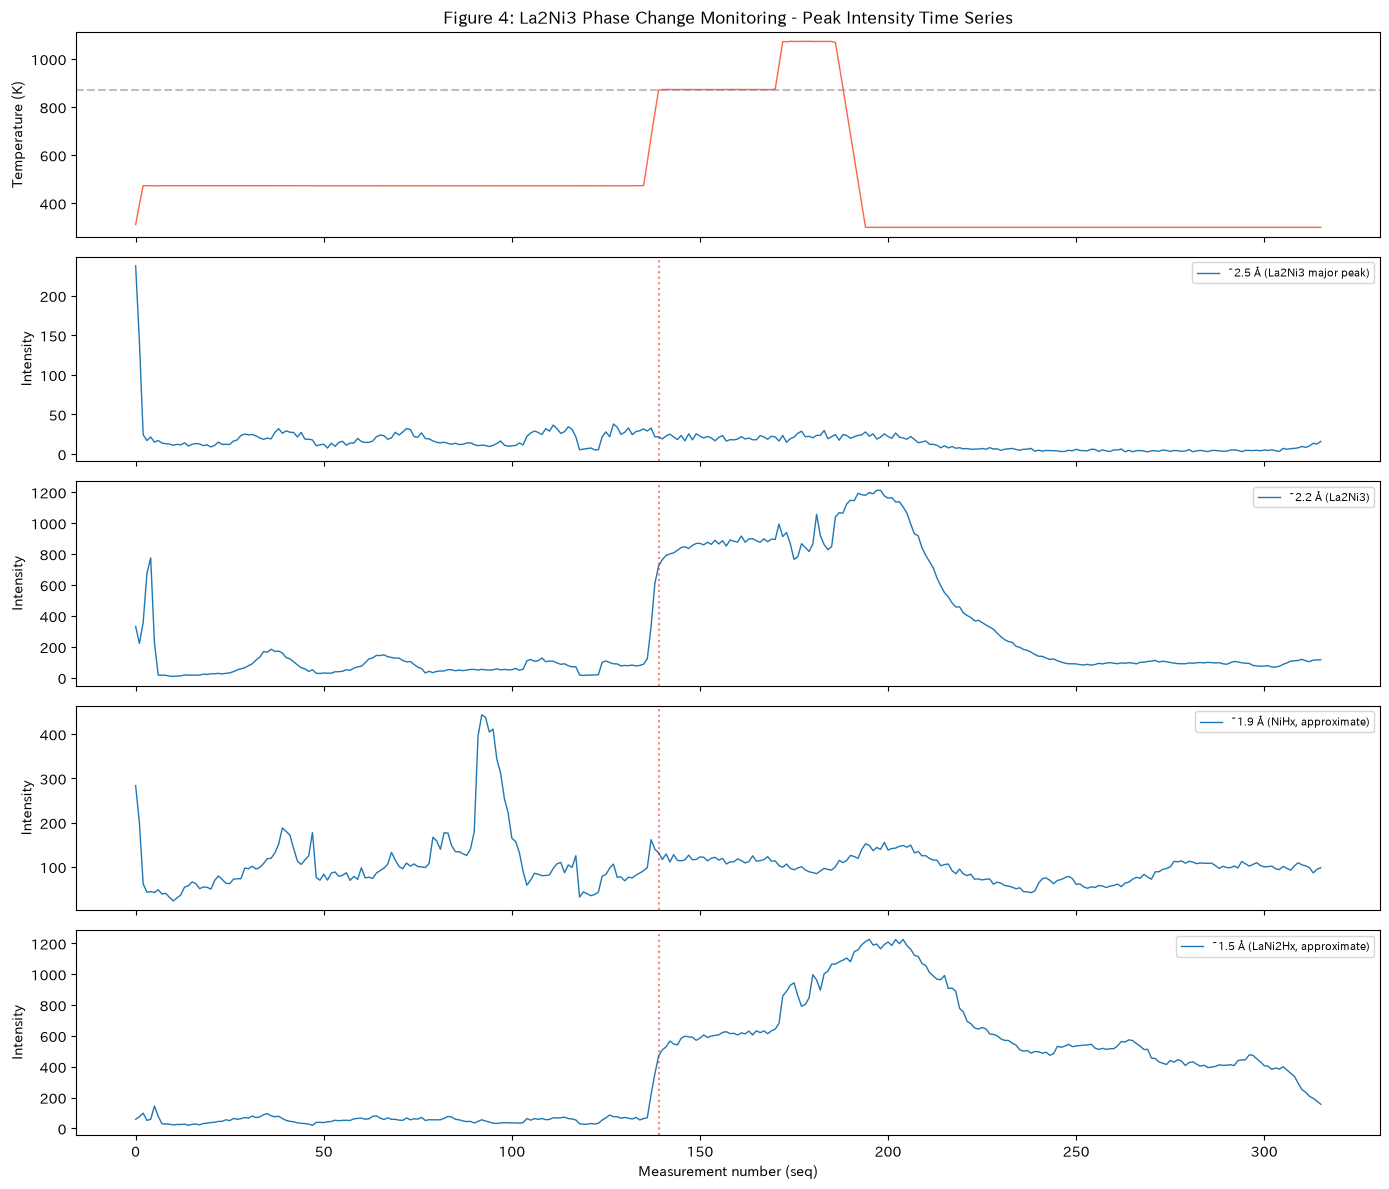

Signal processing complete


In [20]:
# 確認プロット
fig, axes = plt.subplots(len(track_d_values) + 1, 1, figsize=(14, 12), sharex=True)

# 温度軸（共通）
seq_num = np.arange(n_patterns)
axes[0].plot(seq_num, temps, color="tomato", lw=1)
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("Figure 4: La2Ni3 Phase Change Monitoring - Peak Intensity Time Series")
axes[0].axhline(873, color="gray", ls="--", alpha=0.5)

for j, (label, d_val) in enumerate(track_d_values.items()):
    intensities = track_intensity_at_d(I_corrected, d_axis, d_val)
    axes[j+1].plot(seq_num, intensities, lw=1, label=label)
    axes[j+1].set_ylabel("Intensity")
    axes[j+1].legend(loc="upper right", fontsize=8)
    if (temps > 800).any():
        axes[j+1].axvline(seq_num[np.argmax(temps > 800)], color="red", ls=":", alpha=0.5)

axes[-1].set_xlabel("Measurement number (seq)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig04_peak_tracking.png", dpi=150, bbox_inches="tight")
plt.show()
print("Signal processing complete")

## 6. 差分スペクトル（反応前後の比較）

《齋藤さんへの質問事項》　
1. 反応前後としておりますが、水素吸蔵などガス吸着においては、前後における結晶構造の変化がみられるかと思います。そのような場合、とくに留意点はどのようなポイントがありますでしょうか。　（反応前後とする、何かの閾値の考え方、見方）
1. また、反応前後の確認すべきデータはほかにありますか。

### 反応前（T<400K）と反応後（T>850K）の平均パターンを比較

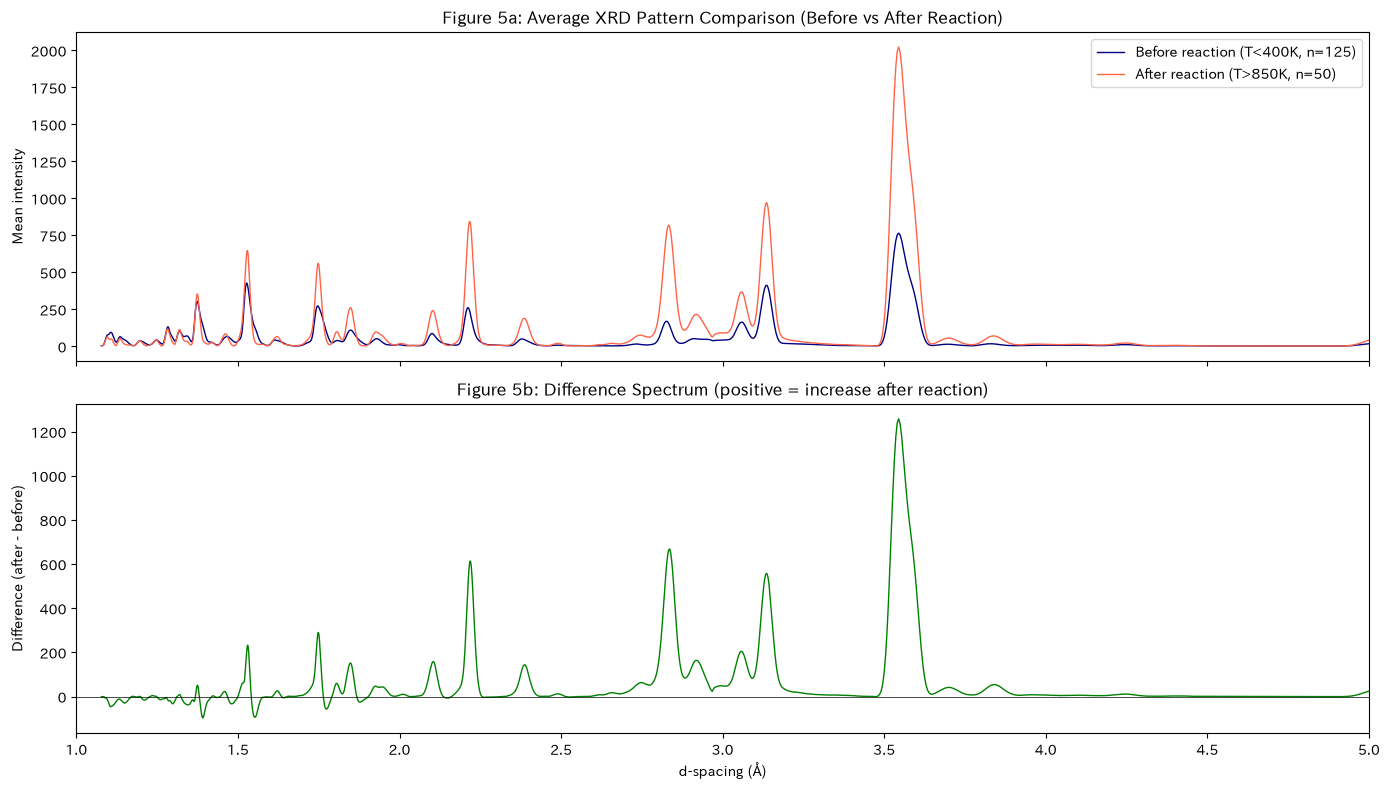

02_signal_processing notebook complete


In [21]:
# 反応前（T<400K）と反応後（T>850K）の平均パターンを比較
mask_before = temps < 400
mask_after = temps > 850

if mask_after.sum() > 0:
    spectrum_before = I_corrected[mask_before].mean(axis=0)
    spectrum_after = I_corrected[mask_after].mean(axis=0)
    diff = spectrum_after - spectrum_before

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(d_axis, spectrum_before, lw=1, color="navy", label=f"Before reaction (T<400K, n={mask_before.sum()})")
    axes[0].plot(d_axis, spectrum_after, lw=1, color="tomato", label=f"After reaction (T>850K, n={mask_after.sum()})")
    axes[0].set_ylabel("Mean intensity")
    axes[0].set_xlim(1.0, 5.0)
    axes[0].legend()
    axes[0].set_title("Figure 5a: Average XRD Pattern Comparison (Before vs After Reaction)")

    axes[1].plot(d_axis, diff, lw=1, color="green")
    axes[1].axhline(0, color="black", lw=0.5)
    axes[1].set_ylabel("Difference (after - before)")
    axes[1].set_xlabel("d-spacing (Å)")
    axes[1].set_xlim(1.0, 5.0)
    axes[1].set_title("Figure 5b: Difference Spectrum (positive = increase after reaction)")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "fig05_diff_spectrum.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Warning: no patterns found above 850K. Relax the temperature threshold.")
print("02_signal_processing notebook complete")

## 7. まとめ・今後の課題・演習問題

本ノートブックは信号処理パイプラインの構築が目的であり、複数モデルの学習・比較は行っていないため、比較表・比較図はここには置いていません（機械学習モデルの比較は`03_machine_learning.ipynb`で扱います）。

### まとめ

- 316パターンの時系列XRDデータを2D配列（測定番号×エネルギーチャンネル）にまとめ、Savitzky-Golayスムージング（window=15, polyorder=3）→移動最小値法によるベースライン補正、という前処理パイプラインを構築した。
- 参照パターン（A2308001、1 GPa室温）に対する`scipy.signal.find_peaks`によるピーク検出結果は、上のセルの実行結果（検出ピーク数・上位10ピークのd値）を参照してください（バージョン依存の可能性があるため、本文には固定値を記載していません）。
- La2Ni3の結晶構造は斜方晶・空間群Cmca (No. 64)であることを一次資料（Van Vucht & Buschow, 1976）で確認した。ただし本ノートブックでは格子定数からの理論d値計算や個々のピークへのMiller指数帰属（indexing）までは行っていない。
- 監視対象のd値（~2.5, ~2.2, ~1.9, ~1.5 Å）は文献が示唆する目安値であり、系統的な指数付けの結果ではない点に注意してください。
- 図5の差分スペクトル（T<400K平均 vs T>850K平均）から、反応前後でどのd値の強度が増減したかを視覚的に確認できる。

### 本ノートブックで扱っていないこと（今後の課題）

- PDindexer等による系統的なピークインデックス・相同定
- Rietveld精密化による格子定数の定量化
- 機械学習によるフェーズの自動分類（→`03_machine_learning.ipynb`）
- 圧力マーカーを用いた圧力の精密化

### 演習問題

1. `savgol_filter`の`window_length`を15から31に変更すると、スムージング後のピーク形状（図2）はどう変化しますか。ノイズ抑制とピーク形状の保持はトレードオフの関係にあることを確認してください。
2. `baseline_correction()`の`window`引数を120から50・300に変えて、ベースライン補正結果（図3）がどう変わるか比較してください。
3. `track_d_values`に新しいd値（例: 3.0 Å）を追加し、その強度の時系列変化（図4）を確認してください。
4. `mask_before`・`mask_after`の温度しきい値（400K, 850K）を変更すると、差分スペクトル（図5）の見え方はどう変わりますか。閾値をどう選ぶべきか、図1の2Dカラーマップと見比べながら考察してください。